<a href="https://colab.research.google.com/github/irene-ch-yeh/colab/blob/main/ntuhw2_wistron_irene_Pb3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from collections import Counter
import time

seed = 11412044
np.random.seed(seed)

# ============================================================
# LABS Cost Functions
# ============================================================
def compute_Ck(s, k):
    """Compute the aperiodic autocorrelation C_k(s) = sum_{i=0}^{N-k-1} s[i]*s[i+k]."""
    N = len(s)
    return sum(s[i] * s[i + k] for i in range(N - k))

def sidelobe_energy(s):
    """Compute sidelobe energy E(s) = sum_{k=1}^{N-1} C_k(s)^2."""
    N = len(s)
    return sum(compute_Ck(s, k) ** 2 for k in range(1, N))

def merit_factor(s):
    """Compute merit factor F(s) = N^2 / (2*E(s))."""
    N = len(s)
    E = sidelobe_energy(s)
    if E == 0:
        return float('inf')
    return N ** 2 / (2.0 * E)

# ============================================================
# Verification 1: Barker-11  +++---+--+-
# ============================================================
barker_11 = [1, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1]

print("=" * 60)
print("Verification: Barker sequence N = 11")
print("Sequence: +++---+--+-")
print("=" * 60)

# Print all autocorrelation values
for k in range(1, 11):
    Ck = compute_Ck(barker_11, k)
    print(f"  C_{k:>2d} = {Ck:>3d}")

E_11 = sidelobe_energy(barker_11)
F_11 = merit_factor(barker_11)
print(f"\n  E(s) = {E_11}   (expected: 5)")
print(f"  F(s) = {F_11:.2f}  (expected: 12.10)")
assert E_11 == 5, f"Barker-11 verification FAILED: E = {E_11}"
assert abs(F_11 - 12.10) < 0.01, f"Barker-11 verification FAILED: F = {F_11}"
print("  ✓ Barker-11 verification PASSED")

# ============================================================
# Verification 2: N = 5  +++−+
# ============================================================
s5 = [1, 1, 1, -1, 1]
E_5 = sidelobe_energy(s5)
F_5 = merit_factor(s5)
print(f"\nVerification: N = 5, s = +++-+")
print(f"  E(s) = {E_5}   (expected: 2)")
print(f"  F(s) = {F_5:.2f}  (expected: 6.25)")
assert E_5 == 2 and abs(F_5 - 6.25) < 0.01
print("  ✓ N=5 verification PASSED")

# ============================================================
# Verification 3: Barker-13
# ============================================================
barker_13 = [1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1]
E_13 = sidelobe_energy(barker_13)
F_13 = merit_factor(barker_13)
print(f"\nVerification: Barker N = 13")
print(f"  E(s) = {E_13}   (expected: 6)")
print(f"  F(s) = {F_13:.3f}  (expected: ≈14.083)")
assert E_13 == 6 and abs(F_13 - 14.083) < 0.01
print("  ✓ Barker-13 verification PASSED")



Verification: Barker sequence N = 11
Sequence: +++---+--+-
  C_ 1 =   0
  C_ 2 =  -1
  C_ 3 =   0
  C_ 4 =  -1
  C_ 5 =   0
  C_ 6 =  -1
  C_ 7 =   0
  C_ 8 =  -1
  C_ 9 =   0
  C_10 =  -1

  E(s) = 5   (expected: 5)
  F(s) = 12.10  (expected: 12.10)
  ✓ Barker-11 verification PASSED

Verification: N = 5, s = +++-+
  E(s) = 2   (expected: 2)
  F(s) = 6.25  (expected: 6.25)
  ✓ N=5 verification PASSED

Verification: Barker N = 13
  E(s) = 6   (expected: 6)
  F(s) = 14.083  (expected: ≈14.083)
  ✓ Barker-13 verification PASSED


In [ ]:
# ============================================================
# Build LABS energy as a spin polynomial
# ============================================================
def build_labs_polynomial(N):
    """
    Build E(s) as a polynomial in spin variables s_0, ..., s_{N-1}.

    Returns: dict mapping (tuple of variable indices) -> coefficient.
    Empty tuple () represents the constant term.

    Uses the simplification rule: s_i^2 = 1 for SPIN variables.
    If an index appears an even number of times, it cancels out.
    """
    poly = {}
    for k in range(1, N):
        for i in range(N - k):
            for j in range(N - k):
                # Term: s_i * s_{i+k} * s_j * s_{j+k}
                indices = [i, i + k, j, j + k]
                # Count occurrences of each index
                cnt = Counter(indices)
                # Keep only indices with odd multiplicity (s_m^2 = 1)
                key = tuple(sorted(idx for idx, c in cnt.items() if c % 2 == 1))
                poly[key] = poly.get(key, 0) + 1
    return poly

def evaluate_spin_polynomial(poly, s):
    """Evaluate the spin polynomial for a given spin configuration s."""
    result = 0
    for key, coeff in poly.items():
        product = 1
        for idx in key:
            product *= s[idx]
        result += coeff * product
    return result

# ============================================================
# Build and analyze polynomial for N = 20
# ============================================================
N = 20

print("\n" + "=" * 60)
print(f"Building LABS spin polynomial for N = {N}")
print("=" * 60)

t0 = time.time()
poly_N = build_labs_polynomial(N)
t_build = time.time() - t0

# Count terms by degree
degree_counts = {}
for key in poly_N:
    d = len(key)
    degree_counts[d] = degree_counts.get(d, 0) + 1

print(f"  Build time: {t_build:.2f}s")
print(f"  Total terms: {len(poly_N)}")
for d in sorted(degree_counts):
    print(f"    Degree-{d}: {degree_counts[d]} terms")

# Expected constant = N(N-1)/2 from identity terms (i=j)
expected_const = N * (N - 1) // 2
actual_const = poly_N.get((), 0)
print(f"\n  Constant term: {actual_const}  (expected N(N-1)/2 = {expected_const})")

# ============================================================
# Cross-verify: polynomial vs direct computation
# ============================================================
print("\nCross-verification (polynomial vs. direct computation):")
test_cases = [
    ("Barker-11", barker_11),
    ("N=5 +++−+", s5),
    ("Barker-13", barker_13),
]
for name, seq in test_cases:
    poly_test = build_labs_polynomial(len(seq))
    E_poly = evaluate_spin_polynomial(poly_test, seq)
    E_direct = sidelobe_energy(seq)
    match = "✓" if E_poly == E_direct else "✗"
    print(f"  {name}: E_poly = {E_poly}, E_direct = {E_direct}  {match}")

# Also verify with random sequences for N=20
print("\n  Random sequence cross-checks for N=20:")
for trial in range(3):
    np.random.seed(seed + trial)
    s_rand = np.random.choice([-1, 1], size=N).tolist()
    E_poly = evaluate_spin_polynomial(poly_N, s_rand)
    E_direct = sidelobe_energy(s_rand)
    match = "✓" if E_poly == E_direct else "✗"
    print(f"    Trial {trial}: E_poly = {E_poly}, E_direct = {E_direct}  {match}")



Building LABS spin polynomial for N = 20
  Build time: 0.02s
  Total terms: 616
    Degree-0: 1 terms
    Degree-2: 90 terms
    Degree-4: 525 terms

  Constant term: 190  (expected N(N-1)/2 = 190)

Cross-verification (polynomial vs. direct computation):
  Barker-11: E_poly = 5, E_direct = 5  ✓
  N=5 +++−+: E_poly = 2, E_direct = 2  ✓
  Barker-13: E_poly = 6, E_direct = 6  ✓

  Random sequence cross-checks for N=20:
    Trial 0: E_poly = 74, E_direct = 74  ✓
    Trial 1: E_poly = 130, E_direct = 130  ✓
    Trial 2: E_poly = 110, E_direct = 110  ✓


In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import minimize

seed = 11412044
np.random.seed(seed)

N = 20

# ── Cost functions (from Part a) ──────────────────────────────
def compute_Ck(s, k):
    return sum(s[i] * s[i + k] for i in range(len(s) - k))

def sidelobe_energy(s):
    return sum(compute_Ck(s, k) ** 2 for k in range(1, len(s)))

def merit_factor(s):
    E = sidelobe_energy(s)
    return len(s) ** 2 / (2.0 * E) if E > 0 else float('inf')

def build_labs_polynomial(N):
    poly = {}
    for k in range(1, N):
        for i in range(N - k):
            for j in range(N - k):
                indices = [i, i + k, j, j + k]
                cnt = Counter(indices)
                key = tuple(sorted(idx for idx, c in cnt.items() if c % 2 == 1))
                poly[key] = poly.get(key, 0) + 1
    return poly

# ── Precompute E_table ────────────────────────────────────────
print("=" * 60)
print(f"Precomputing E_table for all 2^{N} = {2**N:,} sequences ...")
t0 = time.time()

all_indices = np.arange(2**N, dtype=np.int32)
all_spins = np.zeros((2**N, N), dtype=np.int8)
for i in range(N):
    all_spins[:, i] = 1 - 2 * ((all_indices >> (N - 1 - i)) & 1)

E_table = np.zeros(2**N, dtype=np.float64)
for k in range(1, N):
    Ck = np.sum(all_spins[:, :N-k] * all_spins[:, k:], axis=1)
    E_table += Ck.astype(np.float64) ** 2

t_pre = time.time() - t0

E_opt   = E_table.min()
F_opt   = N**2 / (2 * E_opt)
opt_idx = np.where(E_table == E_opt)[0]

print(f"  Done in {t_pre:.2f}s.  E range [{E_table.min():.0f}, {E_table.max():.0f}]")
print(f"  Optimal: E* = {E_opt:.0f},  F* = {F_opt:.4f}")
print(f"  # optimal sequences: {len(opt_idx)}")
for idx in opt_idx[:4]:
    s = all_spins[idx]
    print(f"    {''.join(['+' if x==1 else '-' for x in s])}")

# ── Normalize for QAOA ────────────────────────────────────────
E_mean = np.mean(E_table)
E_std  = np.std(E_table)
E_norm = (E_table - E_mean) / E_std      # zero-mean, unit-variance


Precomputing E_table for all 2^20 = 1,048,576 sequences ...
  Done in 1.92s.  E range [26, 2470]
  Optimal: E* = 26,  F* = 7.6923
  # optimal sequences: 8
    +++++-+---+-++---++-
    ++--+--++++-++++-+-+
    +-+-++++-++++--+--++
    +--+++--+-+++-+-----


In [ ]:
def local_search(s, max_iter=300):
    """Steepest-descent single-bit-flip local search.
    Returns (improved_sequence, final_energy)."""
    s = list(s)
    NL = len(s)
    Ck = [compute_Ck(s, k) for k in range(1, NL)]
    E_cur = sum(c**2 for c in Ck)

    for _ in range(max_iter):
        best_flip, best_dE = -1, 0
        for i in range(NL):
            dE = 0
            for ki in range(NL - 1):          # ki = k-1
                k = ki + 1
                dCk = 0
                if i + k < NL:   dCk -= 2 * s[i] * s[i + k]
                if i - k >= 0:   dCk -= 2 * s[i - k] * s[i]
                dE += 2 * Ck[ki] * dCk + dCk * dCk
            if dE < best_dE:
                best_dE, best_flip = dE, i
        if best_flip < 0:
            break                              # local minimum reached
        # apply flip
        i = best_flip
        for ki in range(NL - 1):
            k = ki + 1
            dCk = 0
            if i + k < NL:  dCk -= 2 * s[i] * s[i + k]
            if i - k >= 0:  dCk -= 2 * s[i - k] * s[i]
            Ck[ki] += dCk
        s[i] *= -1
        E_cur += best_dE
    return s, int(round(E_cur))


In [ ]:
!pip install pennylane --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 101.2 MB/s eta 0:00:00


In [ ]:
# ── PennyLane reference (for clarity) ─────────────────────────
import pennylane as qml

dev_pl = qml.device('default.qubit', wires=N)

@qml.qnode(dev_pl)
def qaoa_probs_pennylane(params):
    p = len(params) // 2
    gammas, betas = params[:p], params[p:]
    for w in range(N):
        qml.Hadamard(wires=w)
    for layer in range(p):
        qml.DiagonalQubitUnitary(
            np.exp(-1j * gammas[layer] * E_norm), wires=range(N))
        for w in range(N):
            qml.RX(2 * betas[layer], wires=w)
    return qml.probs(wires=range(N))


In [ ]:
# ── Fast NumPy simulation (identical physics) ─────────────────
# Pre-build index pairs for the mixer gates (done once)
_all = np.arange(2**N)
_mixer_pairs = []
for q in range(N):
    bit  = 1 << (N - 1 - q)
    idx0 = _all[(_all & bit) == 0]
    idx1 = idx0 | bit
    _mixer_pairs.append((idx0, idx1))

def simulate_qaoa(gammas, betas):
    """Return |prob|^2 vector of length 2^N."""
    psi = np.ones(2**N, dtype=np.complex128) / np.sqrt(2**N)
    for gamma, beta in zip(gammas, betas):
        # cost layer  (diagonal unitary)
        psi *= np.exp(-1j * gamma * E_norm)
        # mixer layer  (RX(2β) on every qubit)
        c  = np.cos(beta)
        ms = -1j * np.sin(beta)
        for idx0, idx1 in _mixer_pairs:
            a, b = psi[idx0].copy(), psi[idx1].copy()
            psi[idx0] = c * a + ms * b
            psi[idx1] = ms * a + c * b
    return np.abs(psi)**2

def qaoa_cost(params):
    """Expected normalized energy <E_norm>."""
    p = len(params) // 2
    probs = simulate_qaoa(params[:p], params[p:])
    return float(np.dot(probs, E_norm))


In [ ]:
def interp_transfer(gammas_p, betas_p):
    """INTERP: transfer params from depth p -> p+1 (Eq. 15)."""
    p = len(gammas_p)
    g_ext = np.concatenate([[0], gammas_p, [0]])   # boundary γ_0 = γ_{p+1} = 0
    b_ext = np.concatenate([[0], betas_p,  [0]])
    g_new = np.zeros(p + 1)
    b_new = np.zeros(p + 1)
    for j in range(p + 1):
        i = j + 1                                  # 1-indexed
        g_new[j] = (i-1)/p * g_ext[i-1] + (p-i+1)/p * g_ext[i]
        b_new[j] = (i-1)/p * b_ext[i-1] + (p-i+1)/p * b_ext[i]
    return g_new, b_new

# ── Run QAOA for p = 1, 2, 3 with INTERP ─────────────────────
print("\n" + "=" * 60)
print("Strategy 1: Quartic QAOA + Local Search")
print("=" * 60)

n_restarts      = 5
maxiter_per_run = 200

qaoa_records = []           # store results for each depth
best_gammas, best_betas = None, None

convergence_qaoa = {}       # {p: list of <E> values}

for p in [1, 2, 3]:
    print(f"\n--- depth p = {p} ---")
    n_params = 2 * p
    best_cost_p   = float('inf')
    best_params_p = None
    conv_list     = []       # convergence trace
    total_evals   = 0

    for trial in range(n_restarts):
        np.random.seed(seed + trial * 37 + p * 1000)

        # Warm-start from INTERP (trials beyond 0 also add noise)
        if p == 1 or best_gammas is None:
            init = np.random.uniform(-np.pi, np.pi, n_params)
        else:
            g_int, b_int = interp_transfer(best_gammas, best_betas)
            init = np.concatenate([g_int, b_int])
            if trial > 0:
                init += 0.3 * np.random.randn(n_params)

        trial_trace = []
        def _cost(params, _trace=trial_trace):
            v = qaoa_cost(params)
            _trace.append(v)
            return v

        res = minimize(_cost, init, method='COBYLA',
                       options={'maxiter': maxiter_per_run, 'rhobeg': 0.5})
        total_evals += len(trial_trace)
        conv_list.extend(trial_trace)

        if res.fun < best_cost_p:
            best_cost_p   = res.fun
            best_params_p = res.x.copy()

    best_gammas = best_params_p[:p]
    best_betas  = best_params_p[p:]

    # ── Sample top candidates & apply local search ────────────
    probs_final = simulate_qaoa(best_gammas, best_betas)
    n_candidates = 50
    top_k = np.argsort(probs_final)[-n_candidates:]

    best_E_ls, best_seq_ls = float('inf'), None
    for idx in top_k:
        s_cand = list(all_spins[idx])
        s_imp, E_imp = local_search(s_cand)
        if E_imp < best_E_ls:
            best_E_ls  = E_imp
            best_seq_ls = s_imp

    # pure QAOA result (highest-probability bitstring)
    pure_idx  = np.argmax(probs_final)
    E_pure    = int(E_table[pure_idx])
    F_pure    = N**2 / (2*E_pure) if E_pure > 0 else float('inf')

    F_ls = merit_factor(best_seq_ls)
    r_ls = F_ls / F_opt
    N_eval = total_evals + n_candidates  # optimizer calls + sampling

    seq_str = ''.join(['+' if x==1 else '-' for x in best_seq_ls])
    print(f"  Pure QAOA        :  E = {E_pure},  F = {F_pure:.4f}")
    print(f"  QAOA + LS (hybrid):  E = {best_E_ls},  F = {F_ls:.4f},  r = {r_ls:.4f}")
    print(f"  N_eval = {N_eval}")
    print(f"  Params: γ = {best_gammas},  β = {best_betas}")
    print(f"  Sequence: {seq_str}")

    qaoa_records.append(dict(
        p=p, E_pure=E_pure, F_pure=F_pure,
        E_hybrid=best_E_ls, F_hybrid=F_ls, r_hybrid=r_ls,
        N_eval=N_eval, gammas=best_gammas.copy(), betas=best_betas.copy()
    ))
    convergence_qaoa[p] = conv_list



Strategy 1: Quartic QAOA + Local Search

--- depth p = 1 ---


/tmp/ipykernel_3135/634419737.py:7: RuntimeWarning: overflow encountered in scalar add
  E_cur = sum(c**2 for c in Ck)
/tmp/ipykernel_3135/634419737.py:18: RuntimeWarning: overflow encountered in scalar add
  dE += 2 * Ck[ki] * dCk + dCk * dCk
/tmp/ipykernel_3135/634419737.py:32: RuntimeWarning: overflow encountered in scalar add
  E_cur += best_dE
/tmp/ipykernel_3135/634419737.py:18: RuntimeWarning: overflow encountered in scalar multiply
  dE += 2 * Ck[ki] * dCk + dCk * dCk


  Pure QAOA        :  E = 2470,  F = 0.0810
  QAOA + LS (hybrid):  E = 46,  F = 4.3478,  r = 0.5652
  N_eval = 871
  Params: γ = [0.89721879],  β = [2.99793879]
  Sequence: -+++---++-++------+-

--- depth p = 2 ---
  Pure QAOA        :  E = 26,  F = 7.6923
  QAOA + LS (hybrid):  E = 26,  F = 7.6923,  r = 1.0000
  N_eval = 1050
  Params: γ = [0.62073002 1.54920422],  β = [2.9910909  3.04686987]
  Sequence: +++++-+---+-++---++-

--- depth p = 3 ---
  Pure QAOA        :  E = 26,  F = 7.6923
  QAOA + LS (hybrid):  E = 26,  F = 7.6923,  r = 1.0000
  N_eval = 1050
  Params: γ = [0.55346132 1.5115148  2.14967282],  β = [2.97702577 3.03788655 3.06625236]
  Sequence: --++-++----+----+-+-


In [ ]:
!pip install dimod dwave-neal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 46.5 MB/s eta 0:00:00


In [ ]:
import dimod
import neal

print("\n" + "=" * 60)
print("Strategy 2: Quadratized Simulated Annealing")
print("=" * 60)

# ── Build HUBO ────────────────────────────────────────────────
t0 = time.time()
poly_dict = build_labs_polynomial(N)
t_build = time.time() - t0

degree_counts = {}
for key in poly_dict:
    d = len(key)
    degree_counts[d] = degree_counts.get(d, 0) + 1

print(f"  HUBO built in {t_build:.2f}s  —  {len(poly_dict)} terms")
for d in sorted(degree_counts):
    print(f"    degree-{d}: {degree_counts[d]}")
print(f"  Constant term = {poly_dict.get((), 0)}  (expected N(N-1)/2 = {N*(N-1)//2})")

# ── Quadratize & solve for several penalty strengths ──────────
# Drop constant term (does not affect the optimizer)
poly_no_const = {k: v for k, v in poly_dict.items() if len(k) > 0}

strengths   = [50, 100, 200]
num_reads   = 2000
sa_sampler  = neal.SimulatedAnnealingSampler()

sa_results = []

for strength in strengths:
    print(f"\n  --- penalty strength = {strength} ---")
    t0 = time.time()
    bp  = dimod.BinaryPolynomial(poly_no_const, vartype=dimod.SPIN)
    bqm = dimod.make_quadratic(bp, strength=strength, vartype=dimod.SPIN)
    t_q = time.time() - t0

    n_vars = len(bqm.variables)
    n_aux  = n_vars - N
    print(f"  Quadratized in {t_q:.2f}s  →  {n_vars} vars ({N} original + {n_aux} aux)")

    t0 = time.time()
    result = sa_sampler.sample(bqm, num_reads=num_reads, seed=seed)
    t_sa = time.time() - t0

    # Extract best original-variable solution across all reads
    best_E_sa, best_seq_sa = float('inf'), None
    for sample in result.samples()[:num_reads]:
        seq = [int(sample[i]) for i in range(N)]
        E_s = sidelobe_energy(seq)
        if E_s < best_E_sa:
            best_E_sa  = E_s
            best_seq_sa = seq

    # Also apply local search to the SA result
    seq_ls, E_ls = local_search(best_seq_sa)
    F_sa  = merit_factor(best_seq_sa)
    F_ls2 = merit_factor(seq_ls)
    r_sa  = F_sa  / F_opt
    r_ls2 = F_ls2 / F_opt

    print(f"  SA time: {t_sa:.2f}s")
    print(f"  SA only      : E = {best_E_sa}, F = {F_sa:.4f}, r = {r_sa:.4f}")
    print(f"  SA + LS       : E = {E_ls}, F = {F_ls2:.4f}, r = {r_ls2:.4f}")

    sa_results.append(dict(
        strength=strength, E_sa=best_E_sa, F_sa=F_sa, r_sa=r_sa,
        E_ls=E_ls, F_ls=F_ls2, r_ls=r_ls2,
        N_eval=num_reads, time=t_q + t_sa, n_vars=n_vars
    ))

# Pick best SA result
best_sa = min(sa_results, key=lambda d: d['E_ls'])
print(f"\n  Best SA + LS overall: E = {best_sa['E_ls']}, "
      f"F = {best_sa['F_ls']:.4f}, r = {best_sa['r_ls']:.4f}")



Strategy 2: Quadratized Simulated Annealing
  HUBO built in 0.01s  —  616 terms
    degree-0: 1
    degree-2: 90
    degree-4: 525
  Constant term = 190  (expected N(N-1)/2 = 190)

  --- penalty strength = 50 ---
  Quadratized in 0.02s  →  360 vars (20 original + 340 aux)
  SA time: 19.11s
  SA only      : E = 38, F = 5.2632, r = 0.6842
  SA + LS       : E = 38, F = 5.2632, r = 0.6842

  --- penalty strength = 100 ---
  Quadratized in 0.02s  →  360 vars (20 original + 340 aux)
  SA time: 18.80s
  SA only      : E = 54, F = 3.7037, r = 0.4815
  SA + LS       : E = 54, F = 3.7037, r = 0.4815

  --- penalty strength = 200 ---
  Quadratized in 0.03s  →  360 vars (20 original + 340 aux)
  SA time: 17.09s
  SA only      : E = 50, F = 4.0000, r = 0.5200
  SA + LS       : E = 50, F = 4.0000, r = 0.5200

  Best SA + LS overall: E = 38, F = 5.2632, r = 0.6842


In [ ]:
best_seq_sa

[1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, 1, 1, -1, 1, -1, -1, 1, -1]

In [ ]:
print("\n" + "=" * 60)
print("Part (b) — Results Summary")
print("=" * 60)
print(f"{'Strategy':<30} {'E_best':>6} {'F_best':>8} {'r':>6} {'N_eval':>7}")
print("-" * 60)
for rec in qaoa_records:
    label = f"S1: QAOA p={rec['p']} + LS"
    print(f"{label:<30} {rec['E_hybrid']:>6} {rec['F_hybrid']:>8.4f} "
          f"{rec['r_hybrid']:>6.4f} {rec['N_eval']:>7}")
label = f"S2: Quad-SA (str={best_sa['strength']})+LS"
print(f"{label:<30} {best_sa['E_ls']:>6} {best_sa['F_ls']:>8.4f} "
      f"{best_sa['r_ls']:>6.4f} {best_sa['N_eval']:>7}")
print(f"\n  Known optimum: E* = {E_opt:.0f}, F* = {F_opt:.4f}")



Part (b) — Results Summary
Strategy                       E_best   F_best      r  N_eval
------------------------------------------------------------
S1: QAOA p=1 + LS                  46   4.3478 0.5652     871
S1: QAOA p=2 + LS                  26   7.6923 1.0000    1050
S1: QAOA p=3 + LS                  26   7.6923 1.0000    1050
S2: Quad-SA (str=50)+LS            38   5.2632 0.6842    2000

  Known optimum: E* = 26, F* = 7.6923


In [ ]:
print("\n" + "=" * 60)
print("Baseline 1: Random Sampling")
print("=" * 60)

np.random.seed(seed)
n_random  = 3000           # comparable budget to strategies
rand_best_E   = float('inf')
rand_best_seq = None
rand_history  = []

for t in range(n_random):
    s = np.random.choice([-1, 1], size=N).tolist()
    E_s = sidelobe_energy(s)
    if E_s < rand_best_E:
        rand_best_E   = E_s
        rand_best_seq = s
    rand_history.append(rand_best_E)

# + local search on the best random sequence
rand_ls_seq, rand_ls_E = local_search(rand_best_seq)

F_rand    = merit_factor(rand_best_seq)
F_rand_ls = merit_factor(rand_ls_seq)
r_rand    = F_rand    / F_opt
r_rand_ls = F_rand_ls / F_opt

print(f"  Random only : E = {rand_best_E}, F = {F_rand:.4f}, r = {r_rand:.4f}")
print(f"  Random + LS : E = {rand_ls_E},  F = {F_rand_ls:.4f}, r = {r_rand_ls:.4f}")



Baseline 1: Random Sampling
  Random only : E = 38, F = 5.2632, r = 0.6842
  Random + LS : E = 38,  F = 5.2632, r = 0.6842


In [ ]:
print("\n" + "=" * 60)
print("Baseline 2: Classical SA (direct on LABS, no quadratization)")
print("=" * 60)

def classical_sa_labs(N, n_steps=3000, T0=50.0, T1=0.01, rng_seed=0):
    rng = np.random.RandomState(rng_seed)
    s = rng.choice([-1, 1], size=N).tolist()
    E_cur  = sidelobe_energy(s)
    best_s = list(s)
    best_E = E_cur
    history = [best_E]
    alpha = (T1 / T0) ** (1.0 / n_steps)
    T = T0
    for _ in range(n_steps):
        i = rng.randint(N)
        s[i] *= -1
        E_new = sidelobe_energy(s)
        dE = E_new - E_cur
        if dE < 0 or rng.random() < np.exp(-dE / T):
            E_cur = E_new
            if E_cur < best_E:
                best_E = E_cur
                best_s = list(s)
        else:
            s[i] *= -1
        T *= alpha
        history.append(best_E)
    return best_s, best_E, history

t0 = time.time()
csa_seq, csa_E, csa_history = classical_sa_labs(N, n_steps=3000, rng_seed=seed)
t_csa = time.time() - t0

csa_ls_seq, csa_ls_E = local_search(csa_seq)
F_csa    = merit_factor(csa_seq)
F_csa_ls = merit_factor(csa_ls_seq)
r_csa    = F_csa    / F_opt
r_csa_ls = F_csa_ls / F_opt

print(f"  SA only  : E = {csa_E}, F = {F_csa:.4f}, r = {r_csa:.4f}  ({t_csa:.2f}s)")
print(f"  SA + LS  : E = {csa_ls_E}, F = {F_csa_ls:.4f}, r = {r_csa_ls:.4f}")



Baseline 2: Classical SA (direct on LABS, no quadratization)
  SA only  : E = 42, F = 4.7619, r = 0.6190  (0.09s)
  SA + LS  : E = 42, F = 4.7619, r = 0.6190


In [ ]:
print("\n" + "=" * 60)
print("Part (c) — Full Comparison Table")
print("=" * 60)

rows = []
rows.append(("Brute Force (exact)", E_opt, F_opt, 1.0, 2**N))
rows.append(("Random Sampling",     rand_best_E, F_rand, r_rand, n_random))
rows.append(("Random + LS",         rand_ls_E, F_rand_ls, r_rand_ls, n_random))
rows.append(("Classical SA",        csa_E, F_csa, r_csa, 3000))
rows.append(("Classical SA + LS",   csa_ls_E, F_csa_ls, r_csa_ls, 3000))
for rec in qaoa_records:
    rows.append((f"QAOA p={rec['p']} (pure)",
                 rec['E_pure'], rec['F_pure'], rec['F_pure']/F_opt, rec['N_eval']))
    rows.append((f"QAOA p={rec['p']} + LS",
                 rec['E_hybrid'], rec['F_hybrid'], rec['r_hybrid'], rec['N_eval']))
for sr in sa_results:
    rows.append((f"Quad-SA (λ={sr['strength']})",
                 sr['E_sa'], sr['F_sa'], sr['r_sa'], sr['N_eval']))
    rows.append((f"Quad-SA (λ={sr['strength']})+LS",
                 sr['E_ls'], sr['F_ls'], sr['r_ls'], sr['N_eval']))

print(f"{'Method':<28} {'E_best':>7} {'F_best':>8} {'r':>7} {'N_eval':>8}")
print("-" * 62)
for (name, E, F, r, ne) in rows:
    print(f"{name:<28} {E:>7.0f} {F:>8.4f} {r:>7.4f} {ne:>8}")



Part (c) — Full Comparison Table
Method                        E_best   F_best       r   N_eval
--------------------------------------------------------------
Brute Force (exact)               26   7.6923  1.0000  1048576
Random Sampling                   38   5.2632  0.6842     3000
Random + LS                       38   5.2632  0.6842     3000
Classical SA                      42   4.7619  0.6190     3000
Classical SA + LS                 42   4.7619  0.6190     3000
QAOA p=1 (pure)                 2470   0.0810  0.0105      871
QAOA p=1 + LS                     46   4.3478  0.5652      871
QAOA p=2 (pure)                   26   7.6923  1.0000     1050
QAOA p=2 + LS                     26   7.6923  1.0000     1050
QAOA p=3 (pure)                   26   7.6923  1.0000     1050
QAOA p=3 + LS                     26   7.6923  1.0000     1050
Quad-SA (λ=50)                    38   5.2632  0.6842     2000
Quad-SA (λ=50)+LS                 38   5.2632  0.6842     2000
Quad-SA (λ=100)      

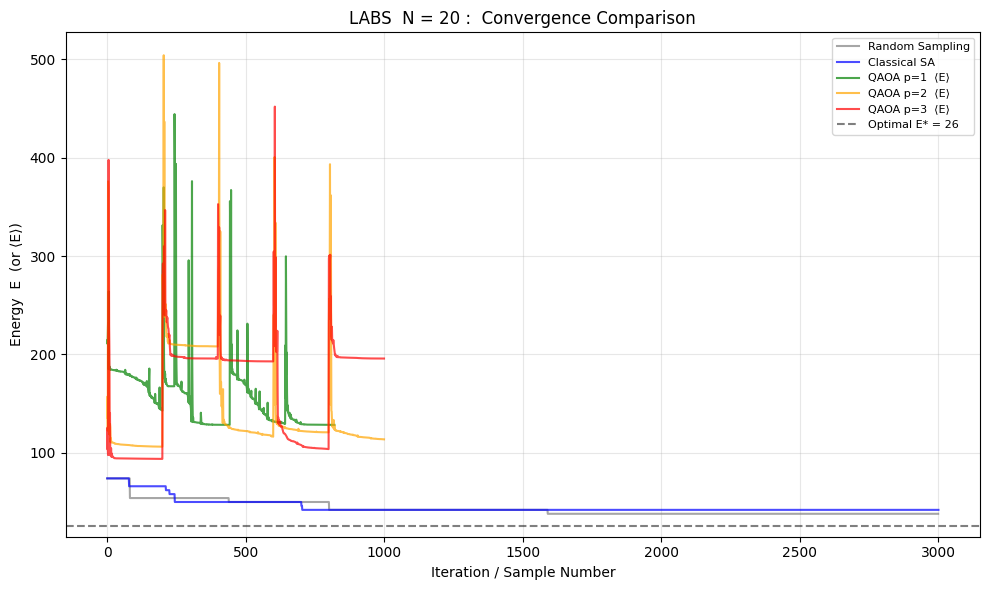

  Saved: labs_convergence.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Random sampling (best-so-far)
ax.plot(range(len(rand_history)), rand_history,
        color='gray', alpha=0.7, label='Random Sampling')

# Classical SA (best-so-far)
ax.plot(range(len(csa_history)), csa_history,
        color='blue', alpha=0.7, label='Classical SA')

# QAOA <E> traces for each depth
qaoa_colors = {1: 'green', 2: 'orange', 3: 'red'}
for p, trace in convergence_qaoa.items():
    # Convert normalized cost back to E scale
    trace_E = np.array(trace) * E_std + E_mean
    ax.plot(range(len(trace_E)), trace_E,
            color=qaoa_colors[p], alpha=0.7,
            label=f'QAOA p={p}  ⟨E⟩')

# Optimal reference line
ax.axhline(y=E_opt, color='black', ls='--', alpha=0.5,
           label=f'Optimal E* = {E_opt:.0f}')

ax.set_xlabel('Iteration / Sample Number')
ax.set_ylabel('Energy  E  (or ⟨E⟩)')
ax.set_title(f'LABS  N = {N} :  Convergence Comparison')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('labs_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: labs_convergence.png")


In [ ]:
csa_seq2, csa_E2, _ = classical_sa_labs(N, n_steps=3000, T0=500.0, rng_seed=seed)

In [ ]:
csa_E2

38